In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'
NUTS1_COLNAME = 'NUTS1_ID'
NUTS2_COLNAME = 'NUTS2_ID'

In [4]:
shapefile_gdf = gpd.read_file(f"../../Europe Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

In [5]:
shapefile_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [6]:
print(f'shapefile\'s CRS before conversion: {shapefile_gdf.crs}')
shapefile_gdf = shapefile_gdf.to_crs(epsg=4326)
print(f'shapefile\'s CRS after conversion: {shapefile_gdf.crs}')

shapefile's CRS before conversion: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
shapefile's CRS after conversion: EPSG:4326


In [7]:
shapefile_gdf[NUTS2_COLNAME].unique()

array(['EL30', 'EL41', 'EL42', 'EL43', 'EL51', 'EL52', 'EL53', 'EL54',
       'EL61', 'EL62', 'EL63', 'EL64', 'EL65'], dtype=object)

In [8]:
nuts3_gdf = shapefile_gdf.loc[shapefile_gdf[NUTS2_COLNAME] == f'{NUTS2_ID}'].copy()
nuts3_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
21,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL521,Imathia,Ημαθία,2.0,2,1,"POLYGON ((22.49137 40.71127, 22.49048 40.69363..."
22,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL522,Thessaloniki,Θεσσαλονίκη,2.0,1,1,"MULTIPOLYGON (((23.76508 40.75789, 23.74400 40..."
23,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL523,Kilkis,Κιλκίς,4.0,3,2,"POLYGON ((22.87918 41.34065, 22.87673 41.33293..."
24,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL524,Pella,Πέλλα,2.0,3,2,"POLYGON ((22.33205 41.12027, 22.33207 41.11894..."
25,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL525,Pieria,Πιερία,4.0,2,1,"POLYGON ((22.66396 40.49155, 22.67067 40.48719..."


<Axes: >

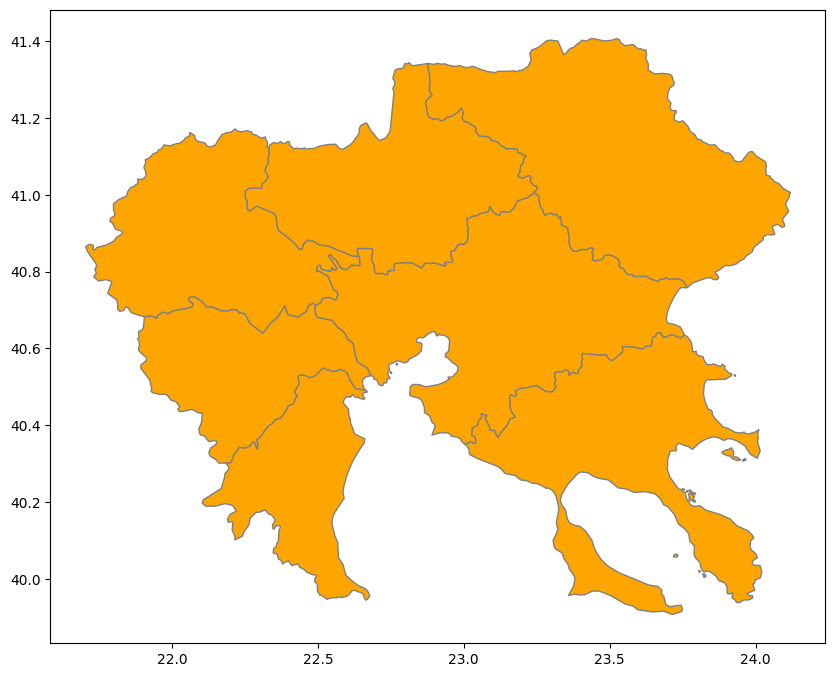

In [9]:
nuts3_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [10]:
nuts2_gdf = nuts3_gdf.dissolve(by = NUTS1_COLNAME, as_index = False)

<Axes: >

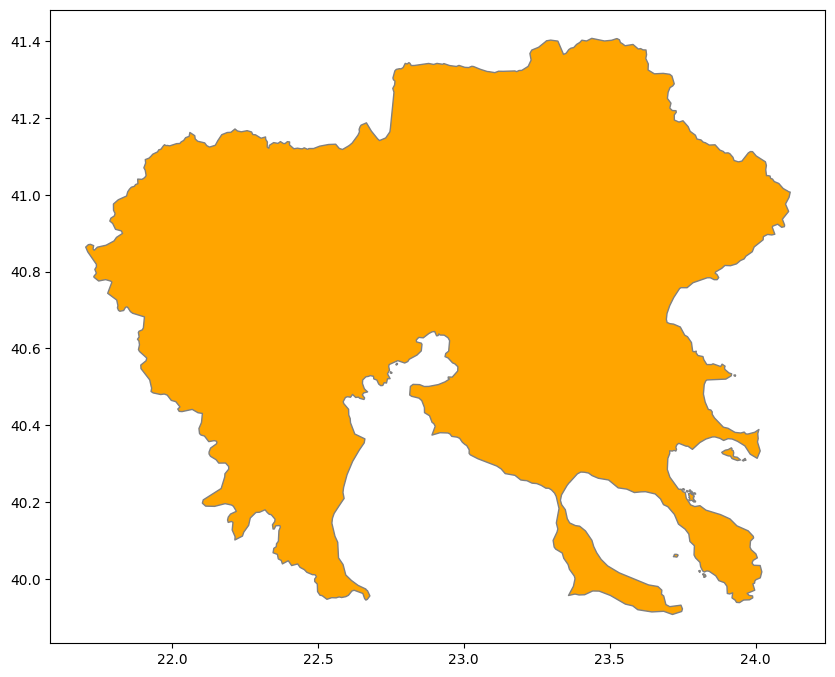

In [11]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [12]:
nuts2_gdf = nuts2_gdf[['NUTS2_ID', 'NUTS2_NAME', 'geometry']]
nuts2_gdf.reset_index(inplace=True, drop = True)

In [13]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal=NUTS2_COLNAME, dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [14]:
df_grid.shape

(4416, 5)

In [15]:
df_grid.head()

,geometry,centers,NUTS2_ID,x,y
0,"POLYGON ((21.77505 40.78908, 21.77505 40.80705...",POINT (21.76333741471462 40.79806323421062),EL52,21.76334,40.79806
1,"POLYGON ((21.77505 40.80705, 21.77505 40.82501...",POINT (21.76333741471462 40.816029925810845),EL52,21.76334,40.81603
2,"POLYGON ((21.77505 40.82501, 21.77505 40.84298...",POINT (21.76333741471462 40.83399661741106),EL52,21.76334,40.83400
3,"POLYGON ((21.77505 40.84298, 21.77505 40.86095...",POINT (21.76333741471462 40.85196330901128),EL52,21.76334,40.85196
4,"POLYGON ((21.79847 40.78908, 21.79847 40.80705...",POINT (21.786759980600472 40.79806323421062),EL52,21.78676,40.79806


<Axes: >

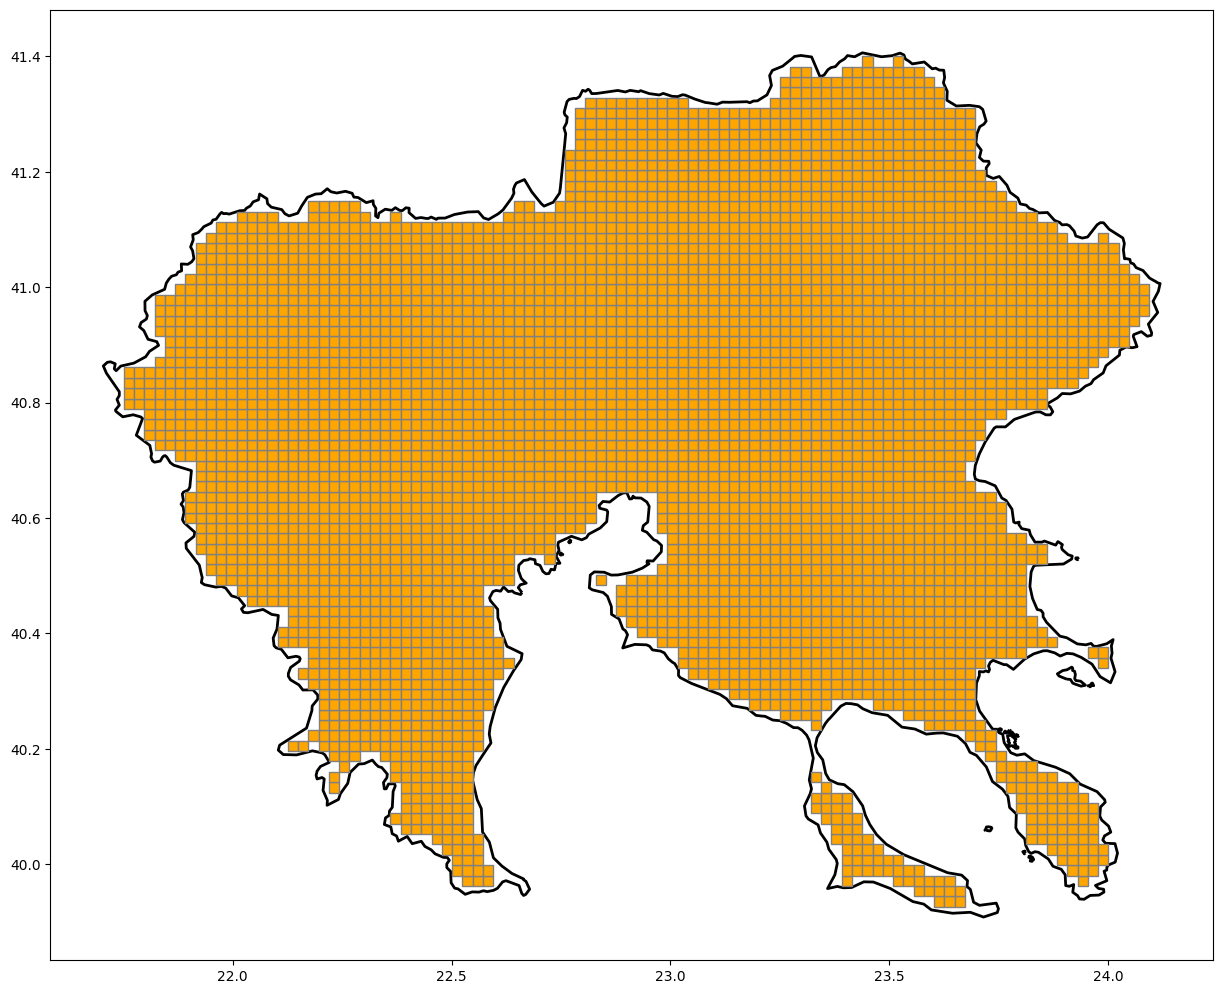

In [16]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [17]:
df_grid.set_geometry('centers', inplace=True)

In [18]:
gdf_merged = gpd.sjoin(df_grid, nuts3_gdf, how='left', op='within')
gdf_merged.set_geometry('geometry', inplace=True)

<Axes: >

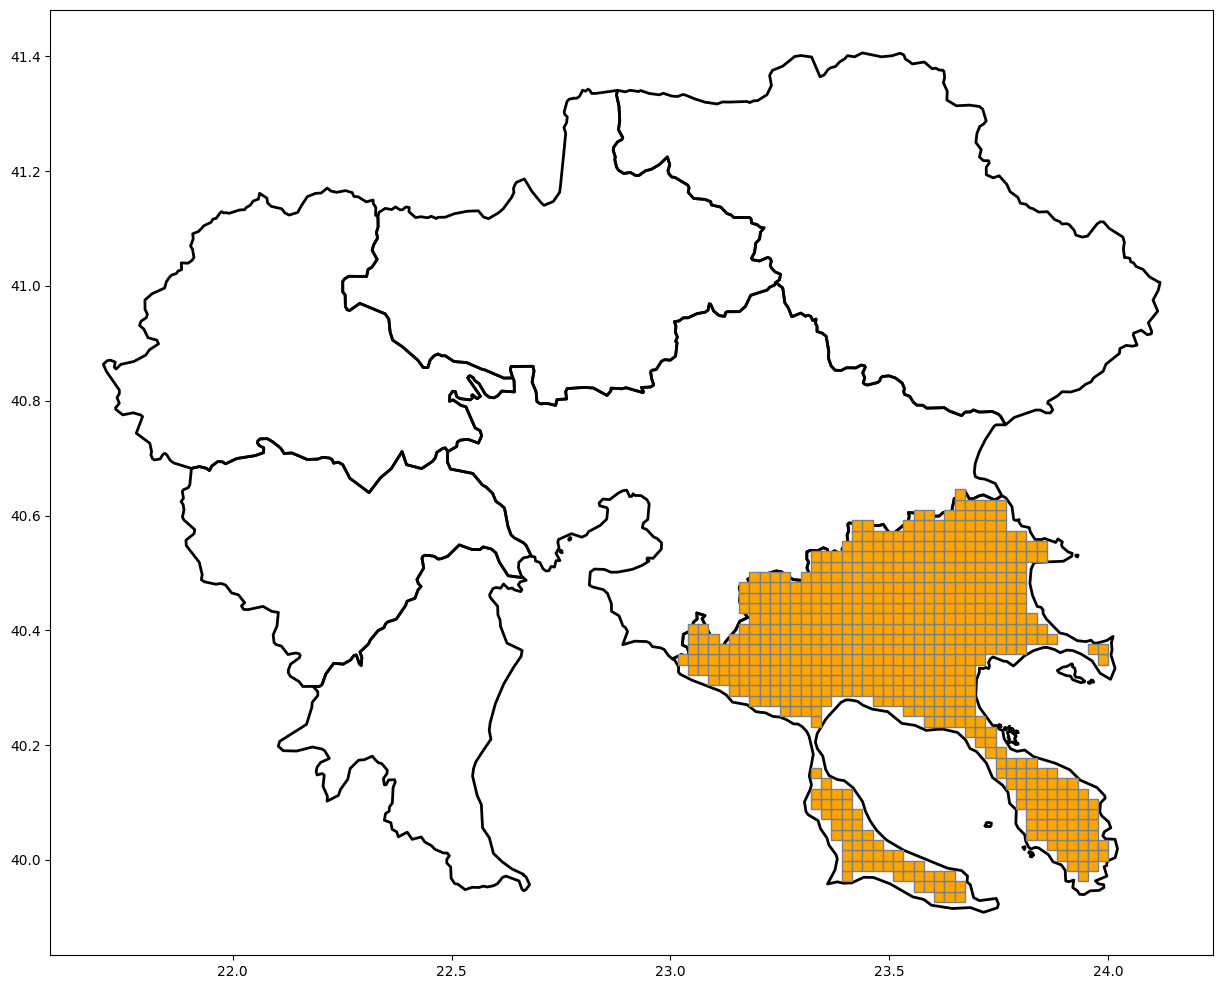

In [19]:
ax = nuts3_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
gdf_merged[gdf_merged['NUTS3_ID'] == 'EL527'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [20]:
gdf_merged.head()

,geometry,centers,NUTS2_ID_left,x,y,index_right,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID_right,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,"POLYGON ((21.77505 40.78908, 21.77505 40.80705...",POINT (21.76334 40.79806),EL52,21.76334,40.79806,24,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL524,Pella,Πέλλα,2.0,3,2
1,"POLYGON ((21.77505 40.80705, 21.77505 40.82501...",POINT (21.76334 40.81603),EL52,21.76334,40.81603,24,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL524,Pella,Πέλλα,2.0,3,2
2,"POLYGON ((21.77505 40.82501, 21.77505 40.84298...",POINT (21.76334 40.83400),EL52,21.76334,40.83400,24,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL524,Pella,Πέλλα,2.0,3,2
3,"POLYGON ((21.77505 40.84298, 21.77505 40.86095...",POINT (21.76334 40.85196),EL52,21.76334,40.85196,24,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL524,Pella,Πέλλα,2.0,3,2
4,"POLYGON ((21.79847 40.78908, 21.79847 40.80705...",POINT (21.78676 40.79806),EL52,21.78676,40.79806,24,EL,Greece,EL5,Voreia Elláda,Βόρεια Ελλάδα,EL52,Kentriki Makedonia,Κεντρική Μακεδονία,EL524,Pella,Πέλλα,2.0,3,2


In [21]:
final_grid = gdf_merged[['NUTS2_ID_left', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'geometry']]
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'NUTS2_ID_left': "NUTS2_ID"}, inplace=True)
final_grid.sort_values(by=['NUTS3_ID', 'x', 'y'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

In [22]:
final_grid['cell_code'] = final_grid['NUTS3_ID'] + pd.Series(final_grid.index + 1).apply(lambda x: f"{x:06d}")
process_greek(final_grid, 'NUTS3_NAME')
process_greek(final_grid, 'NUTS2_NAME')

In [23]:
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'cell_code', 'geometry']]

In [24]:
final_grid.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,cell_code,geometry
0,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.90387,40.60043,EL521000001,"POLYGON ((21.91558 40.59145, 21.91558 40.60941..."
1,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.90387,40.61840,EL521000002,"POLYGON ((21.91558 40.60941, 21.91558 40.62738..."
2,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.90387,40.63636,EL521000003,"POLYGON ((21.91558 40.62738, 21.91558 40.64535..."
3,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.92730,40.54653,EL521000004,"POLYGON ((21.93901 40.53755, 21.93901 40.55551..."
4,EL52,κεντρικη μακεδονια,EL521,ημαθια,21.92730,40.56450,EL521000005,"POLYGON ((21.93901 40.55551, 21.93901 40.57348..."


In [25]:
final_grid.drop(columns='geometry').to_csv(f'../data/GR_CMacedonia_Grid.csv', encoding=enc, index = False)
final_grid.to_file(f'../data/GR_CMacedonia_Grid.shp', encoding = 'utf-8')